## 10. Generación del Baseline: Indicadores Técnicos Clásicos (Manual Features)

Este notebook tiene como objetivo construir el Dataset de Control (Baseline) para la comparativa principal de la investigación. Utilizando la librería personalizada src.technical_indicators, transformamos la señal limpia obtenida en la fase de preprocesamiento en un espacio de características basado en el análisis técnico financiero tradicional.

La finalidad es contrastar el rendimiento de estas "features manuales" frente a las representaciones aprendidas automáticamente mediante técnicas de State Representation Learning (SRL) en las fases posteriores.

In [1]:
import pandas as pd
import numpy as np

import sys
sys.path.append('../')

import src.technical_indicators as ti

Se definen los marcos temporales de estudio (1h y 1d) y se sincronizan las rutas de acceso para leer exclusivamente los outputs generados en el Notebook 01. Esto garantiza que tanto el Baseline como los futuros Embeddings partan de la misma señal estacionaria y libre de ruido (MODWT), asegurando la integridad científica de la comparativa.

In [2]:
#ref_data_range = "1D"
# ref_data_range = "1H"
from_date = '2021-12-31 00:00:00' # 2020-12-31 00:00:00
until_date = '2025-07-31 00:00:00'
until_date_2 = '2025-08-01 00:00:00'

# Convertimos las fechas a formato de nombre de archivo (Safe Strings)
from_safe = from_date.replace(":", "-").replace(" ", "_")
until_safe = until_date.replace(":", "-").replace(" ", "_")

In [3]:
# list_data_name = ["BTCUSDT_1d", "ETHUSDT_1d", "BNBUSDT_1d", "XRPUSDT_1d", "ADAUSDT_1d", "LTCUSDT_1d"]
# list_data_name = ["BTCUSDT_1h", "ETHUSDT_1h", "BNBUSDT_1h", "XRPUSDT_1h", "ADAUSDT_1h", "LTCUSDT_1h"]

# list_data_name = ["ADAUSDT_1h"]
list_data_name = ["SPY_1h"]
#list_data_name = ["BTCUSDT_1h"]

foldername = "SP500"
#foldername = "BTC"

# Extracción de características financieras

Para cada activo, se aplica la función compute_technical_indicators(), la cual inyecta inteligencia financiera al dataset mediante tres categorías de indicadores:

1. Tendencia: Medias móviles exponenciales (EMA) y simples (SMA).

2. Momentum: Índices de fuerza relativa (RSI) y MACD.

3. Volatilidad: Bandas de Bollinger y Average True Range (ATR).

Se realiza una limpieza final de valores nulos (NaN) derivados del periodo de cálculo (lookback) de los indicadores para asegurar la continuidad del entrenamiento del agente.

In [4]:
for data_name in list_data_name:
    # 1. Importación
    ccy = data_name.split('_')[0]
    tf = data_name.split('_')[1]
    input_file = f'../data/{foldername}/01-output-{ccy}_{tf}-from-{from_safe}-until-{until_safe}-log-return.csv'
    
    print(f"\n--- Procesando {tf.upper()}: {input_file} ---")
    data = pd.read_csv(input_file, parse_dates=['date'], index_col='date')

    # 2. LIMPIEZA CRÍTICA: Eliminamos las Wavelets (WTMRA) y normalizaciones previas
    # Solo queremos las columnas de precio bruto (OHLC) para el Baseline
    columnas_prohibidas = [c for c in data.columns if 'wtmra' in c or 'normalized' in c]
    data_baseline = data.drop(columns=columnas_prohibidas)

    # 3. CÁLCULO DE INDICADORES (Sobre los datos limpios)
    # Ahora sí, calculamos RSI, MACD, etc., sobre el precio real
    data_baseline = ti.compute_technical_indicators(data_baseline)
    
    # 4. AÑADIR FEATURES DE RETORNO (Con el shift(1) que pusimos en la lib)
    data_baseline = ti.OHLC_features(data_baseline)

    # 5. Limpieza de NaNs generados por los indicadores y el shift
    data_baseline = data_baseline.dropna()

    # 6. Guardado del archivo
    output_file = f'../data/{foldername}/02-baseline-{ccy}_{tf}-from-{from_safe}-until-{until_safe}-technical-indicators.csv'
    data_baseline.to_csv(output_file, index=True)
    
    print(f"Éxito: Baseline generado con {data_baseline.shape[1]} columnas (sin Leakage).")


--- Procesando 1H: ../data/SP500/01-output-SPY_1h-from-2021-12-31_00-00-00-until-2025-07-31_00-00-00-log-return.csv ---
Éxito: Baseline generado con 49 columnas (sin Leakage).


Se contrastan los indicadores generados con la serie de precios original. Esta validación asegura que las bandas de volatilidad y los osciladores de momentum capturan correctamente la dinámica del mercado, sirviendo como señales de entrada fiables para el agente DQN.

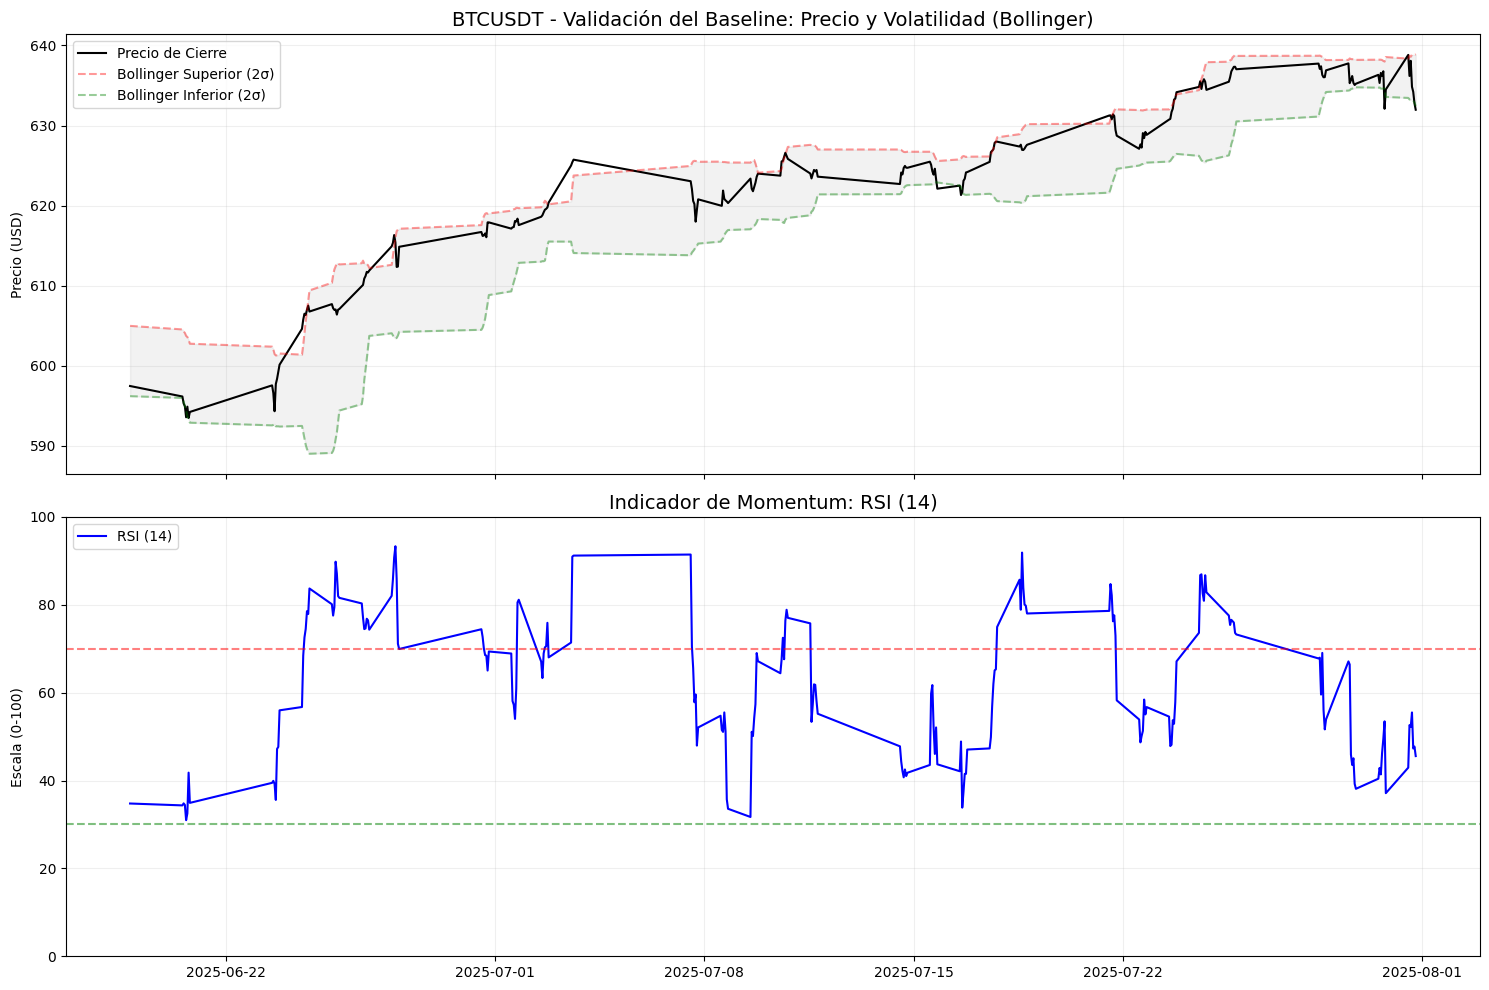

Dataset de Baseline listo 


In [5]:
import matplotlib.pyplot as plt

# Seleccionamos los últimos 200 periodos para que la gráfica sea legible
plot_df = data_baseline.tail(200)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# 1. Gráfico Superior: Precio y Bandas de Bollinger (Usamos la desviación 2.0 que es la estándar)
ax1.plot(plot_df.index, plot_df['close'], label='Precio de Cierre', color='black', linewidth=1.5)
ax1.plot(plot_df.index, plot_df['VolI_BB_Upper_Band_20_2_Feature'], '--', color='red', alpha=0.4, label='Bollinger Superior (2σ)')
ax1.plot(plot_df.index, plot_df['VolI_BB_Lower_Band_20_2_Feature'], '--', color='green', alpha=0.4, label='Bollinger Inferior (2σ)')
ax1.fill_between(plot_df.index, plot_df['VolI_BB_Lower_Band_20_2_Feature'], plot_df['VolI_BB_Upper_Band_20_2_Feature'], color='gray', alpha=0.1)

ax1.set_title('BTCUSDT - Validación del Baseline: Precio y Volatilidad (Bollinger)', fontsize=14)
ax1.set_ylabel('Precio (USD)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.2)

# 2. Gráfico Inferior: RSI (Usamos el periodo estándar de 14)
ax2.plot(plot_df.index, plot_df['MI_RSI_14_Feature'], color='blue', label='RSI (14)')
ax2.axhline(70, color='red', linestyle='--', alpha=0.5) # Zona de sobrecompra
ax2.axhline(30, color='green', linestyle='--', alpha=0.5) # Zona de sobreventa

ax2.set_title('Indicador de Momentum: RSI (14)', fontsize=14)
ax2.set_ylabel('Escala (0-100)')
ax2.set_ylim(0, 100)
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

print(f"Dataset de Baseline listo ")

El dataset de Baseline se ha guardado correctamente en la carpeta data/. Este archivo constituye los "features manuales" que permitirá evaluar si los Embeddings latentes aprendidos por la IA son capaces de superar al análisis técnico tradicional en la toma de decisiones del agente.